# 00 — Dataset EDA
This notebook inspects `data/index.csv`, plots class counts, checks invalid valence/arousal (== -2), and shows a few sample images.


In [1]:
# Ensure project root is on sys.path so `src/*` can be imported when running from notebooks/
import sys
from pathlib import Path
ROOT = Path().resolve()
if (ROOT/'src').exists():
    sys.path.append(str(ROOT))
elif (ROOT.parent/'src').exists():
    sys.path.append(str(ROOT.parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from src.config import DATA_DIR, IMG_DIR

df = pd.read_csv(DATA_DIR/'index.csv')
display(df.head())
print("Rows:", len(df))


,filename,expression,valence,arousal,landmarks,box
0,0.jpg,0,-0.176846,-0.077640,"[[-0.00666666666666534, 81.49801169590643], [2...",NaN
1,1.jpg,0,-0.367789,0.183895,"[[44.95157894736842, 103.7217391304348], [45.3...",NaN
2,2.jpg,4,-0.062911,0.532327,"[[-11.397055655296231, 105.91594936708861], [-...",NaN
3,3.jpg,0,0.004839,-0.004839,"[[-11.303629893238433, 77.82095238095238], [-1...",NaN
4,4.jpg,2,-0.642857,-0.507936,"[[40.75334579439253, 88.69027667984192], [39.0...",NaN


Rows: 3999


Class counts:
 expression
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    499
Name: count, dtype: int64


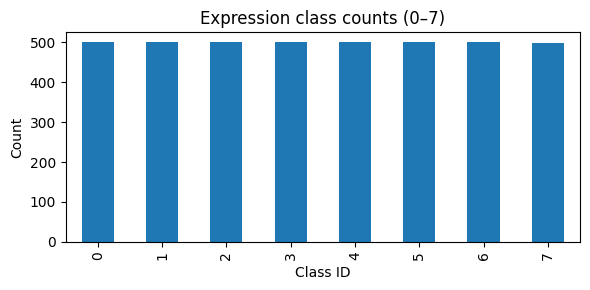

Invalid valence (-2): 0 / 3999
Invalid arousal (-2): 0 / 3999


In [2]:
#class histogram & invalid VA counts
counts = df['expression'].value_counts().sort_index()
print("Class counts:\n", counts)

plt.figure(figsize=(6,3))
counts.plot(kind='bar')
plt.title('Expression class counts (0–7)')
plt.xlabel('Class ID'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

# Invalid valence/arousal counts (-2 means Uncertain/No-face)
n_val_bad = int((df['valence']==-2).sum())
n_aro_bad = int((df['arousal']==-2).sum())
print(f"Invalid valence (-2): {n_val_bad} / {len(df)}")
print(f"Invalid arousal (-2): {n_aro_bad} / {len(df)}")


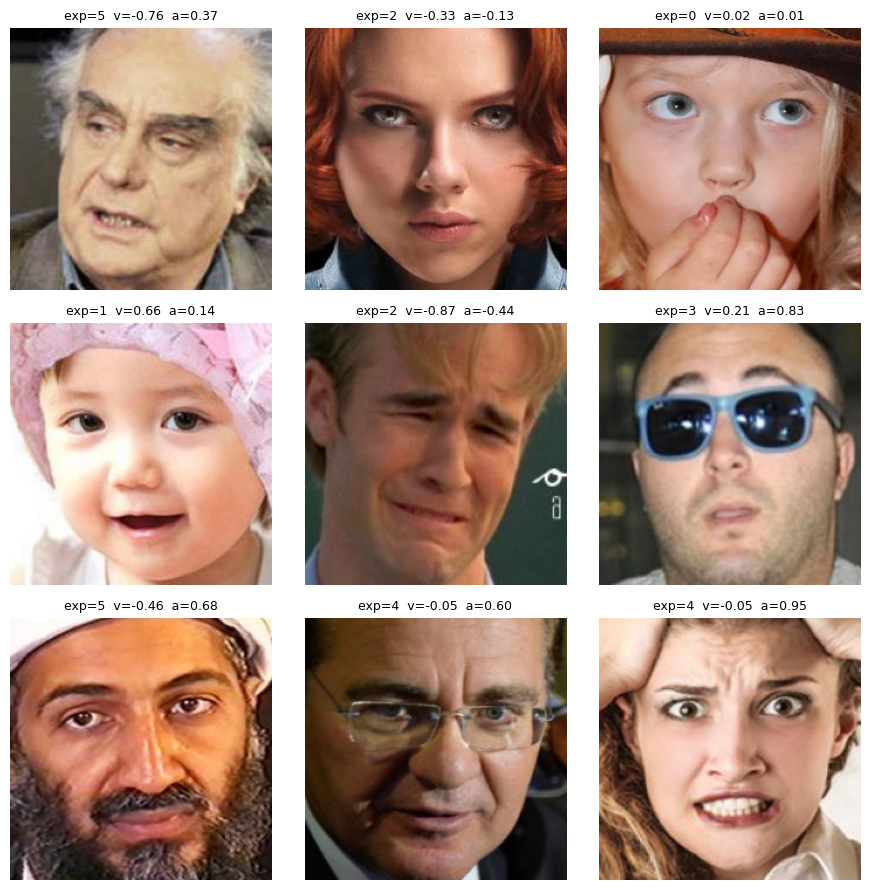

In [3]:
#sample images
sel = df.sample(n=min(9, len(df)), random_state=42).reset_index(drop=True)

rows = 3; cols = 3
plt.figure(figsize=(cols*3, rows*3))
for i in range(min(len(sel), rows*cols)):
    row = sel.iloc[i]
    img = cv2.cvtColor(cv2.imread(str(IMG_DIR/row['filename'])), cv2.COLOR_BGR2RGB)
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"exp={row['expression']}  v={row['valence']:.2f}  a={row['arousal']:.2f}", fontsize=9)
plt.tight_layout(); plt.show()
